#### DBSCAN(밀도 기반 군집화)

- 밀도 기반의 클러스터링 알고리즘으로 데이터의 밀도를 이용하여 군집을 생성
- 데이터가 빽빽한(고밀도) 지역을 하나의 군집으로 생성하고 드문(저밀도) 지역은 노이즈(이상치)로 판단
- KMeans와는 다르게 군집의 개수를 지정할 필요 없다
- 비선형 구조의 데이터에서도 군집 형성이 가능(원형, 나선형의 구조 데이터에서 패턴 분석 가능)
- 노이즈를 판단함으로 이상치에 대한 자동 감지
- 스케일링은 일반적으로 사용(Standard, min-max)

- parameter
    - eps
        - 기본값 : 0.5
        - 두 개의 샘플이 같은 군집으로 간주되기 위한 최대의 거리 (반경)
        - 스케일이 된 데이터를 기준으로 한다면 eps는 최대 2정도로 설정
        - 스케일링이 되지 않는 데이터를 기준으로 한다면 eps 피쳐 안의 데이터의 범위에 따라 값이 변한다
    - min_samples
        - 기본값 : 5
        - 핵심점(core point)으로 판단하기 위한 샘플의 개수
    - metric
        - 기본값 : euclidean
        - 거리 계산 방식
    - algorithm
        - 기본값 : 'auto'
        - 이웃 탐색 알고리즘
        - 'auto' -> 자동 선택, 데이터 특성에 따라 알고리즘 자동 선택
        - 'brute' -> 모든 점 간의 거리를 계산 -> 데이터의 개수가 적은 경우 사용
        - 'kd_tree' -> 저차원 데이터(20차원 이하)에서 매우 빠른 성능
        - 'ball_tree' -> 고차원 데이터에서 효율적인 거리 탐색(공간 분할 기반)
    - leaf_size
        - 기본값 : 30
        - Tree 알고리즘 사용하는 경우 리프의 크기를 지정 (미세한 성능을 조절할때 사용)

- 속성
    - core_sample_indices_
        - 핵심점의 인덱스의 목록
    - components_
        - 핵심점 좌표 배열
    - labels_
        - 각 데이터의 군집의 라벨 (노이즈는 -1로 표시)

- 메서드
    - fit()
    - predict()

- 동작의 원리
    1. 핵심점을 생성( 각 점의 대해서 이웃점의 개수를 계산 )
    2. 경계점을 생성 ( 핵심점 근처에 데이터가 존재하지만 자신이 핵심이 아닌 경우 )
    3. 노이즈점을 생성 ( 어떠한 군집에도 속하지 않은 데이터 )
    4. 핵심점에서 시작해서 이웃을 계속 측정하여 확장하면서 군집을 형성

- 파라미터 튜닝 팁
    - 너무 많은 노이즈가 생성이 된다?
        - eps 증가 시키거나 min_samples 감소
    - 군집이 너무 뭉치는 경우
        - eps 감소
    - 너무 고차원인 경우
        - 차원 축소를 통해서 고차원 데이터를 저차원으로 변경하고 사용
    - 속도가 너무 느리다
        - algorithm을 kd_tree로 변경하거나 n_jobs를 -1로 변경

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [36]:
df = pd.read_csv('../data/bodyPerformance.csv')

In [37]:
obj_cols = df.select_dtypes('object').columns
le = LabelEncoder()

for col in obj_cols:
    df[col] = le.fit_transform(df[col])

In [38]:
x = df.drop(['class'], axis = 1)
y1 = df['class']
y2 = df['gender']

In [39]:
# 스케일링
x_std = StandardScaler().fit_transform(x)

In [40]:
# x 데이터에서 k번째 최근접 이웃의 거리를 계산
# NearestNeighbors : 기존 데이터들 중에서 거리상 가장 가까운 k개의 이웃 데이터를 찾아 내는 역할
# n_neighbors 매개변수 -> 몇번째 이웃 데이터를 찾아낼 것인가
nbrs = NearestNeighbors(n_neighbors=10).fit(x_std)
# kneighbors() -> 특정 데이터와 가장 가까운 이웃들 간의 '거리'와 '위치(인덱스)'를 직접 계산해서 반환해주는 함수(핵심 기능)
distances, idxs = nbrs.kneighbors(x_std)

In [41]:
pd.DataFrame(idxs)

,0,1,2,3,4,5,6,7,8,9
0,0,10928,6644,7587,7791,5946,6208,10666,2702,8099
1,1,8193,1343,12712,12986,3662,3420,9088,12604,9392
2,2,8425,9331,3437,9990,7353,6248,4942,4168,9289
3,3,10765,5724,6686,12121,4454,12815,1973,2499,157
4,4,6368,2943,8795,7089,1753,1521,2540,9458,8720
...,...,...,...,...,...,...,...,...,...,...
13388,13388,6686,2843,10817,6878,11021,7960,4454,3045,12121
13389,13389,7722,5642,4640,877,4272,7778,3860,4527,9923
13390,13390,4557,2090,7515,10906,202,4027,4972,10884,8256
13391,13391,5579,3705,7895,11128,9683,12338,3886,1660,11446


In [42]:
# 각각의 거리 데이터에서 10번째 이웃의 거리만 추출
kth_list = np.sort(distances[:, -1])

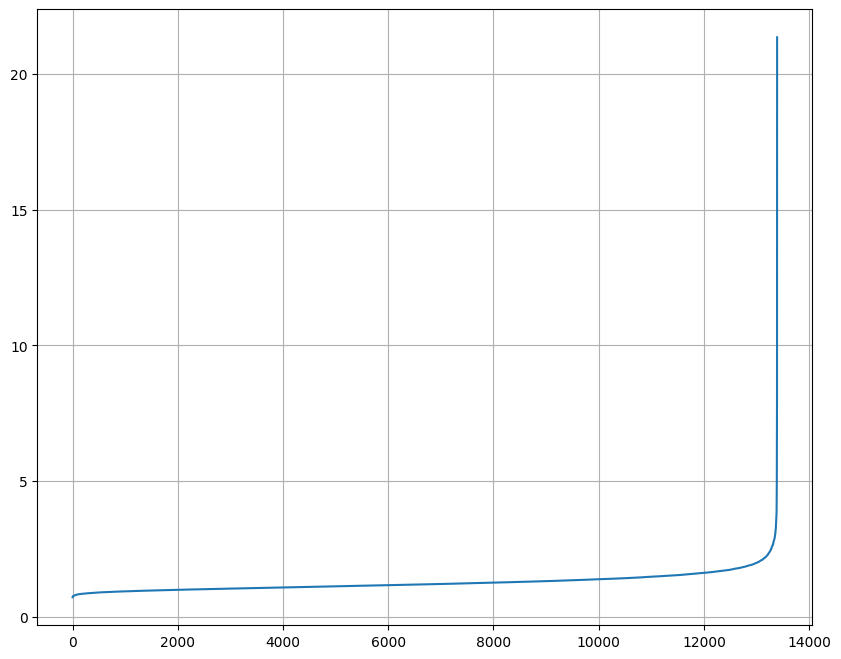

In [43]:
plt.figure(figsize=(10,8))
plt.plot(kth_list)
plt.grid(True)
plt.show()

In [44]:
# eps -> 꺾이는 지점(기울기 변화가 큰 지점 eps)

diffs = np.diff(kth_list)
diffs

array([2.05561147e-02, 4.17030652e-03, 2.95242168e-03, ...,
       1.63507109e+00, 9.98022906e+00, 3.23074202e+00])

In [45]:
eps_ = np.where(diffs > 0.05 )[0]

In [46]:
eps_

array([13357, 13370, 13371, 13374, 13376, 13378, 13380, 13382, 13383,
       13384, 13385, 13386, 13387, 13388, 13389, 13390, 13391],
      dtype=int64)

In [47]:
print('급변하는 인덱스의 값 : ', eps_)
print('대략적인 eps의 최적의 값 : ', kth_list[eps_[0]])

급변하는 인덱스의 값 :  [13357 13370 13371 13374 13376 13378 13380 13382 13383 13384 13385 13386
 13387 13388 13389 13390 13391]
대략적인 eps의 최적의 값 :  3.051458810772378


In [52]:
# body data를 스케일링을 했을 때 최적의 거리는 3으로 지정하면 군집이 깔끔하게 완성 -> 3??? -> 굉장히 큰 수치
db = DBSCAN(
    eps = 1.7,
    min_samples=10,
    n_jobs = -1
)

# 모델에 대한 학습 및 예측
labels = db.fit_predict(x_std)

In [53]:
set(labels)

{-1, 0, 1}

In [55]:
# 노이즈를 제외한 labels의 개수를 확인
np.sum(labels == -1)

341

In [56]:
# 검증 지표
# 노이즈를 제외하고 검증
flag = labels != -1
sil = silhouette_score(x_std[flag], labels[flag])
ari = adjusted_rand_score(y2, labels)

print(sil)

print(ari)

0.34661294803178216
0.9454826679347285


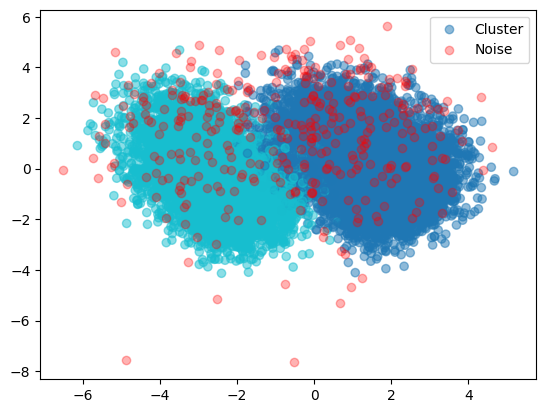

In [57]:
# PCA를 이용하여 2차원으로 차원 축소하고 그래프 시각화
pca = PCA(n_components=2, random_state=42)

x_pca = pca.fit_transform(x_std)

# 노이즈 / 비노이즈 부분을 다르게 표시
non_noise = labels != -1

#  비노이즈 산점도 그래프 표시
plt.scatter(x_pca[non_noise, 0], x_pca[non_noise,1],c=labels[non_noise],cmap='tab10',label = 'Cluster', alpha = 0.5)

# 노이즈 산점도 그래프 표시
plt.scatter(x_pca[~non_noise, 0], x_pca[~non_noise, 1], c= 'red', label = 'Noise', alpha = 0.3)

plt.legend()
plt.show()

In [58]:
# eps -> 반경 -> 줄였을때 노이즈의 개수가 실제로 변하는가?
db2 = DBSCAN(
    eps = 1.3,
    min_samples=10,
    n_jobs=-1
)

labels2 = db2.fit_predict(x_std)

In [59]:
np.sum(labels2 == -1)

1943

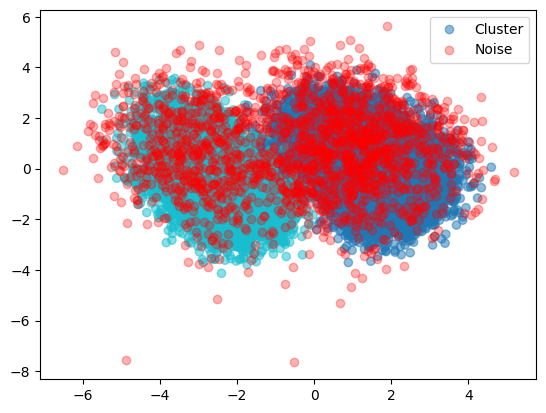

In [60]:
# 노이즈 / 비노이즈 부분을 다르게 표시
non_noise = labels2 != -1

#  비노이즈 산점도 그래프 표시
plt.scatter(x_pca[non_noise, 0], x_pca[non_noise,1],c=labels[non_noise],cmap='tab10',label = 'Cluster', alpha = 0.5)

# 노이즈 산점도 그래프 표시
plt.scatter(x_pca[~non_noise, 0], x_pca[~non_noise, 1], c= 'red', label = 'Noise', alpha = 0.3)

plt.legend()
plt.show()